# Lightcast Job-Postings Regressions — Michigan County RN/LPN Demand

**Data.** `final-regressions-data.csv` with corrected IPEDS pipeline columns and newly merged Lightcast columns: `rn_postings`, `lpn_postings` (unique job postings, county × year, 2010–2023), plus `rn_post_wage_annual` and `lpn_post_wage_annual` (median advertised salary when Lightcast has enough postings to report a wage; NaN otherwise).

**What this notebook is for.** The companion notebook `regressions_explore.ipynb` used residence-based licensure counts as the outcome — a *stock* measure of how many nurses live in each county. This notebook flips the question: job postings as a *flow* measure of how many nurse positions employers are trying to fill in each county-year.

**What a posting actually measures.** A job posting is neither pure demand nor pure supply. It is a vacancy — what is left after the local labor market has already adjusted. In Beveridge-curve terms, vacancies are *excess demand at the going wage*: postings rise when demand outstrips supply, or when supply contracts at a given level of demand. Coefficients on a true demand shifter (e.g., share aged 65+) and on a true supply shifter (e.g., lagged local nurse density) are both identifiable in principle, but their interpretation has to respect the equilibrium structure.

**What this notebook contributes.**

1. A new outcome with within-county time variation that residence-licensure cannot capture — employers hire where they need labor, not necessarily where it currently lives.
2. A direct test of the supply-gap (Beveridge) mechanism via lagged residence-based supply on the right-hand side.
3. A descriptive comparison of advertised and realized wages.

**What this notebook does NOT do.**

- Use the advertised wage as an instrument for the realized wage. Lightcast posted wages reflect what employers *offer*, not what they *pay*; they are jointly chosen by the employer alongside the posting decision.
- Claim that postings causally drive supply or vice versa. The Beveridge relationship is bidirectional. We articulate which arrows we *can* read causally and which we cannot.

**Causal-credibility ladder for the postings outcome** (high → low):

1. `share_65plus` — predetermined demographic; causal-leaning demand shifter.
2. `ipeds_*_per_10k_lag1` — predetermined pipeline; identifies whether training output reduces local vacancies.
3. `*_per_100k_lag1` (lagged residence supply) — predetermined relative to current postings; identifies the supply-gap (Beveridge) channel.
4. `bachelors_plus_share`, `poverty_rate` — slow-moving but endogenous; conditional associations only.
5. Capacity (`hosp_beds_per_1k`, `nh_beds_per_65plus_ahrf`) — co-determined with both supply and postings; conditioning information only.
6. Wages (`rn_pums_wage`, `rn_post_wage_annual`, OEWS) — endogenously set; descriptive only.

**Headline estimator choice.** The variance decomposition in Section A and the Chen–Roth–Sant'Anna (2024) critique of `log(1 + x)` justify making `postings_per_10k` (linear TWFE) and `postings` (PPML with two-way FE) the headline outcomes. The log specifications are retained in Sections C–E for transparency, but Section F flips to per-10K and adds the PPML cell, and Section G interprets PPML as the structural semi-elasticity reading.

In [87]:
import warnings; warnings.filterwarnings('ignore')
import pandas as pd, numpy as np
from linearmodels.panel import PanelOLS
import pyfixest as pf
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

df = pd.read_csv('../final-regressions-data.csv', low_memory=False, dtype={'fips': str})
df['fips'] = df['fips'].str.zfill(5)
df = df.sort_values(['fips', 'year']).reset_index(drop=True)

# Lagged residence supply — for the supply-gap (Beveridge) test
df['rn_per_100k_lag1']  = df.groupby('fips')['rn_per_100k'].shift(1)
df['lpn_per_100k_lag1'] = df.groupby('fips')['lpn_per_100k'].shift(1)

print(f'Panel: {df.shape}')
print(f'  Year range:        {int(df.year.min())} – {int(df.year.max())}')
print(f'  Counties:          {df.fips.nunique()}')
print(f'  RN postings non-null:  {df.rn_postings.notna().sum()}')
print(f'  LPN postings non-null: {df.lpn_postings.notna().sum()}')
print(f'  RN posted-wage non-null:  {df.rn_post_wage_annual.notna().sum()}')
print(f'  LPN posted-wage non-null: {df.lpn_post_wage_annual.notna().sum()}')

Panel: (1162, 143)
  Year range:        2010 – 2023
  Counties:          83
  RN postings non-null:  1160
  LPN postings non-null: 1160
  RN posted-wage non-null:  921
  LPN posted-wage non-null: 720


## Section A — Outcome variable construction

A raw posting count is dominated by Wayne County (over 18{,}000 RN postings in some years against fewer than 50 in many rural counties). Two transformations sit in the panel:

- **`*_postings_per_10k`** — postings divided by county population × 10,000. Comparable across counties; right-skewed but linearly interpretable.
- **`log_*_postings`** — $\log(1 + \text{postings})$. Linearizes the skew and is sometimes read as a semi-elasticity. The `+1` shift handles zero-posting cells (rural counties with no postings in some years), but contaminates the semi-elasticity interpretation when zeros are present — see Section F and Chen, Roth & Sant'Anna (2024).

We run both transformations and then a Poisson pseudo-maximum-likelihood (PPML) specification that uses the raw count directly. The variance decomposition immediately below shows why this choice matters in practice.

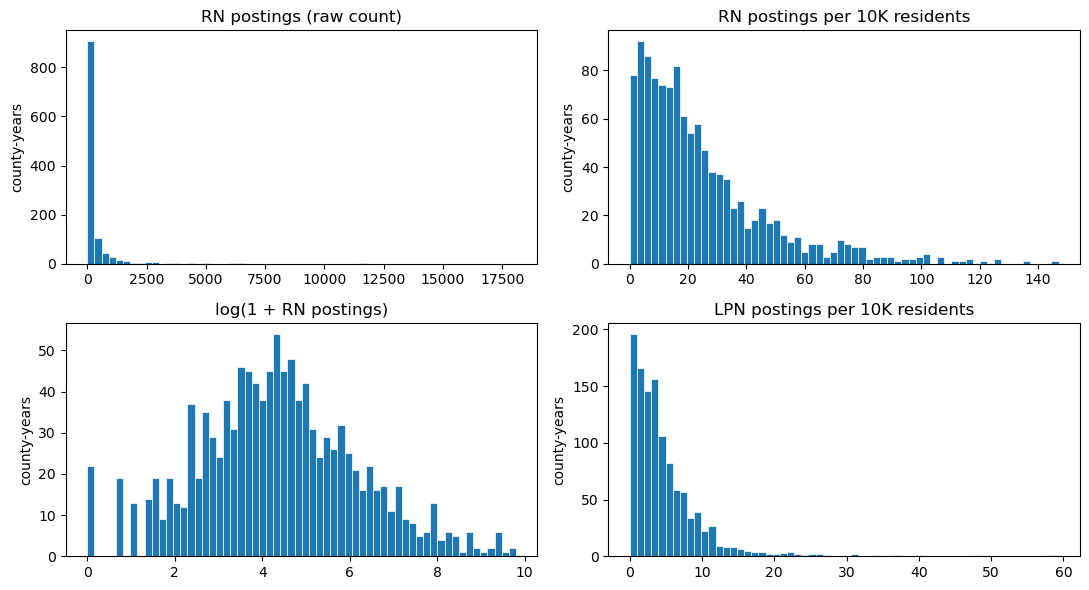


=== Outcome summary ===
                         count    mean       std   min    25%    50%     75%        max
rn_postings          1,160.000 453.270 1,490.070 0.000 22.000 72.500 240.250 18,086.000
rn_postings_per_10k  1,160.000  24.530    22.600 0.000  8.440 18.000  32.650    147.040
log_rn_postings      1,160.000   4.330     1.850 0.000  3.140  4.300   5.490      9.800
lpn_postings         1,160.000  53.040   132.780 0.000  5.000 15.000  40.000  1,764.000
lpn_postings_per_10k 1,160.000   4.760     5.370 0.000  1.570  3.410   6.170     59.330
log_lpn_postings     1,160.000   2.770     1.530 0.000  1.790  2.770   3.710      7.480


In [88]:
# Outcome distributions
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 2, figsize=(11, 6))
for ax, col, title in [
    (axes[0,0], 'rn_postings',          'RN postings (raw count)'),
    (axes[0,1], 'rn_postings_per_10k',  'RN postings per 10K residents'),
    (axes[1,0], 'log_rn_postings',      'log(1 + RN postings)'),
    (axes[1,1], 'lpn_postings_per_10k', 'LPN postings per 10K residents'),
]:
    ax.hist(df[col].dropna(), bins=60, edgecolor='white', linewidth=0.5)
    ax.set_title(title); ax.set_ylabel('county-years')
plt.tight_layout(); plt.show()

print('\n=== Outcome summary ===')
print(df[['rn_postings','rn_postings_per_10k','log_rn_postings',
          'lpn_postings','lpn_postings_per_10k','log_lpn_postings']]
        .describe().T.round(2).to_string())

### Variance decomposition: how much is between-county vs. within-county?

In a TWFE design only the **within-county** variation identifies coefficients. If most of the variation lives between counties — driven by persistent urban/rural differences — county fixed effects will absorb it and TWFE will be noisy. The cell below reports the share of the total variance in each outcome that survives county-demeaning. A small within-share means the FE has eaten almost everything; a large within-share means the model has real signal to identify coefficients from.

In [89]:
def variance_share(y, group='fips'):
    s = df[[group, y]].dropna()
    if s.empty: return None
    total = s[y].var(ddof=0)
    within = s.groupby(group)[y].transform(lambda x: x - x.mean()).var(ddof=0)
    between = total - within
    return {'total': total, 'within': within, 'between': between,
            'within_share': within/total}

for y in ['rn_postings_per_10k', 'log_rn_postings',
          'lpn_postings_per_10k', 'log_lpn_postings',
          'rn_per_100k', 'lpn_per_100k']:
    v = variance_share(y)
    if v is None: continue
    print(f'{y:30s}  within share = {v["within_share"]:.3f}')

rn_postings_per_10k             within share = 0.595
log_rn_postings                 within share = 0.171
lpn_postings_per_10k            within share = 0.677
log_lpn_postings                within share = 0.254
rn_per_100k                     within share = 0.112
lpn_per_100k                    within share = 0.247


## Section B — TWFE shell

Same setup as the residence-supply notebook: county and year fixed effects, standard errors clustered at the county. One TWFE helper, run under matched control sets across the specifications below.

In [90]:
def twfe(data, y_col, xs, label):
    sub = data.dropna(subset=[y_col] + xs).copy().set_index(['fips', 'year'])
    if sub.empty:
        print(f'\n=== {label}: empty ==='); return None
    try:
        res = PanelOLS(sub[y_col], sub[xs], entity_effects=True, time_effects=True,
                        drop_absorbed=True, check_rank=False).fit(
                        cov_type='clustered', cluster_entity=True)
        _ = res.std_errors
        cov_label = 'clustered'
    except Exception:
        try:
            res = PanelOLS(sub[y_col], sub[xs], entity_effects=True, time_effects=True,
                            drop_absorbed=True, check_rank=False).fit(cov_type='robust')
            cov_label = 'robust (cluster SE failed)'
        except Exception as e:
            print(f'\n=== {label}: failed ({type(e).__name__}) ===')
            return None
    print(f'\n=== {label} ===')
    print(f'  N={res.nobs}  counties={sub.index.get_level_values(0).nunique()}  '
          f'years={sub.index.get_level_values(1).nunique()}  '
          f'within R²={res.rsquared:.3f}  cov={cov_label}')
    tbl = pd.DataFrame({'coef': res.params, 'cl_se': res.std_errors,
                        't': res.tstats, 'p': res.pvalues}).round(3)
    print(tbl.to_string()); return res

# Same control families as the nurse-supply notebook
xs_demand   = ['share_65plus']
xs_capacity = ['hosp_beds_per_1k', 'nh_beds_per_65plus_ahrf']
xs_disadv   = ['poverty_rate', 'bachelors_plus_share']
xs_full     = xs_demand + xs_capacity + xs_disadv

## Section C — RN postings as outcome

### C1. Baseline — demand + capacity + disadvantage + pipeline (lag-1)

**C1 — RN postings baseline (log and per-10K outcomes, no wage, no lagged supply)**

*What this regression does.* Two-way fixed effects regression of RN postings on a standard set of predetermined demand shifters, slow-moving disadvantage controls, and capacity conditioning variables, plus the lag-1 IPEDS pipeline. No wage variable.

*Limitations.* Within-$R^2$ is small (0.6–4% on log; ~3% on per-10K). The log specification only uses ~17% of the within-county variance — most of the identifying signal has been absorbed by the FE — so a null in the log spec is much weaker evidence of no effect than a null in the per-10K spec. Capacity coefficients are conditioning information, not causal estimates.

*What the coefficients CAN be read as.* Predetermined regressors — `share_65plus`, the lag-1 pipeline — are causal-leaning conditional on the predetermined assumption (aging and last year's graduating class are not influenced by this year's posting decisions). A within-county positive coefficient on `share_65plus` is consistent with a demand-pressure channel.

*What they CANNOT be read as.* Capacity coefficients (hospital beds, NH beds) cannot be read as the effect of expanding capacity — capacity is built where employers are already hiring. The pipeline coefficient sign is theoretically ambiguous: negative means new graduates absorb vacancies, null means the workplace-vs-residence gap blocks the channel.

In [91]:
res_C1_rn = twfe(df, 'log_rn_postings',
                  xs_full + ['ipeds_rn_per_10k_lag1'],
                  'RN postings (log) — TWFE baseline')


=== RN postings (log) — TWFE baseline ===
  N=994  counties=83  years=12  within R²=0.003  cov=clustered
                          coef  cl_se      t     p
share_65plus             0.006  0.045  0.129 0.897
hosp_beds_per_1k         0.011  0.039  0.291 0.771
nh_beds_per_65plus_ahrf -0.009  0.003 -2.970 0.003
poverty_rate             0.003  0.025  0.125 0.900
bachelors_plus_share    -0.015  0.024 -0.649 0.516
ipeds_rn_per_10k_lag1   -0.003  0.004 -0.833 0.405


In [92]:
res_C1_rn_pc = twfe(df, 'rn_postings_per_10k',
                     xs_full + ['ipeds_rn_per_10k_lag1'],
                     'RN postings per 10K — TWFE baseline')


=== RN postings per 10K — TWFE baseline ===
  N=994  counties=83  years=12  within R²=0.023  cov=clustered
                          coef  cl_se      t     p
share_65plus            -1.109  1.425 -0.778 0.437
hosp_beds_per_1k         1.424  0.927  1.537 0.125
nh_beds_per_65plus_ahrf -0.639  0.097 -6.611 0.000
poverty_rate             1.113  0.611  1.823 0.069
bachelors_plus_share     0.080  0.640  0.126 0.900
ipeds_rn_per_10k_lag1   -0.035  0.093 -0.373 0.709


### C2. Add lagged residence supply (the supply-gap / Beveridge test)

**C2 — RN postings on prior-year residence supply (Beveridge test)**

*What this regression does.* Adds `rn_per_100k_lag1` — last year's residence-based RN density — to the C1 baseline. Predetermined relative to current postings, so reverse causation from current postings to current residence supply is blocked.

*Limitations.* Residence supply is not the same as workplace supply. The lagged-supply coefficient combines a 'labor market is tight here' effect with a 'people who work here don't live here' artifact, and the design cannot separate the two. The Beveridge reading is also an equilibrium statement, not a structural treatment effect: it identifies the within-county co-movement of postings and a one-year-delayed supply measure.

*What the coefficients CAN be read as.* A negative and significant coefficient is consistent with the supply-gap story: counties that lost nurses last year have more vacancies this year. A null says residence-supply does not map onto workplace vacancies at this horizon — exactly what the residence-vs-workplace caveat predicts.

*What they CANNOT be read as.* Even a clean negative coefficient does not identify a structural elasticity of vacancies with respect to supply, because both are equilibrium objects and the design has no instrument for either. Magnitudes are within-county year-to-year associations conditional on the FE, not the long-run supply–vacancy schedule.

In [93]:
res_C2_rn = twfe(df, 'log_rn_postings',
                  xs_full + ['ipeds_rn_per_10k_lag1', 'rn_per_100k_lag1'],
                  'RN postings (log) — TWFE + lagged supply')


=== RN postings (log) — TWFE + lagged supply ===
  N=828  counties=83  years=10  within R²=0.006  cov=clustered
                          coef  cl_se      t     p
share_65plus            -0.013  0.061 -0.204 0.838
hosp_beds_per_1k        -0.020  0.032 -0.634 0.526
nh_beds_per_65plus_ahrf -0.015  0.004 -3.984 0.000
poverty_rate             0.012  0.027  0.427 0.669
bachelors_plus_share    -0.009  0.026 -0.362 0.718
ipeds_rn_per_10k_lag1   -0.001  0.003 -0.251 0.802
rn_per_100k_lag1        -0.000  0.000 -0.196 0.845


### C3. Add wage as RHS — descriptive only

**C3 — RN postings with a wage variable on the right-hand side**

*What this regression does.* Adds either the PUMS realized county wage (C3a) or the Lightcast advertised wage from the same postings (C3b) to the baseline. We run both purely to document the within-county correlation.

*Limitations.* Posted wages and posting counts are simultaneously chosen by the employer subject to a budget. The PUMS realized wage is a market-clearing equilibrium object. There is no instrument here, no exogenous wage shock, no design that breaks the simultaneity. The 2SLS Bartik specification from the companion notebook (first-stage $F < 1$ in MI) is not rescued by adding Lightcast covariates.

*What the coefficients CAN be read as.* Sign and magnitude of the within-county wage-postings correlation, useful as a descriptive fact about how Lightcast advertised wages and the residual posting-volume series move together.

*What they CANNOT be read as.* Any causal reading of the wage coefficient: 'higher wages cause more/fewer postings' is not identified. The same applies in either direction — postings → wages is also jointly determined. Do not quote this coefficient as a labor-supply or labor-demand elasticity.

In [94]:
# C3a — with PUMS realized wage
res_C3a_rn = twfe(df, 'log_rn_postings',
                   xs_full + ['ipeds_rn_per_10k_lag1', 'rn_pums_wage'],
                   'RN postings (log) — TWFE + PUMS wage (descriptive)')


=== RN postings (log) — TWFE + PUMS wage (descriptive) ===
  N=745  counties=83  years=9  within R²=0.006  cov=clustered
                          coef  cl_se      t     p
share_65plus            -0.003  0.056 -0.061 0.952
hosp_beds_per_1k        -0.027  0.042 -0.636 0.525
nh_beds_per_65plus_ahrf -0.001  0.003 -0.177 0.860
poverty_rate            -0.026  0.027 -0.969 0.333
bachelors_plus_share     0.003  0.031  0.102 0.919
ipeds_rn_per_10k_lag1   -0.004  0.005 -0.707 0.480
rn_pums_wage            -0.003  0.005 -0.502 0.616


In [95]:
# C3b — with Lightcast advertised wage (jointly determined with postings)
res_C3b_rn = twfe(df, 'log_rn_postings',
                   xs_full + ['ipeds_rn_per_10k_lag1', 'rn_post_wage_annual'],
                   'RN postings (log) — TWFE + Lightcast advertised wage')


=== RN postings (log) — TWFE + Lightcast advertised wage ===
  N=804  counties=82  years=12  within R²=0.020  cov=clustered
                          coef  cl_se      t     p
share_65plus            -0.033  0.058 -0.568 0.570
hosp_beds_per_1k        -0.035  0.081 -0.435 0.663
nh_beds_per_65plus_ahrf -0.010  0.003 -3.581 0.000
poverty_rate             0.011  0.023  0.451 0.652
bachelors_plus_share     0.028  0.020  1.368 0.172
ipeds_rn_per_10k_lag1   -0.003  0.003 -1.151 0.250
rn_post_wage_annual      0.000  0.000  2.379 0.018


## Section D — LPN postings as outcome

The same four specifications, repeated for LPN. The substantive reading is the same as for RN, with one difference: LPN labor markets are less geographically mobile, so the residence-vs-workplace gap is narrower and the lagged-residence-supply test (D2 = LPN counterpart of C2) is a better proxy for the workplace supply that the postings outcome captures.

In [96]:
res_C1_lpn = twfe(df, 'log_lpn_postings',
                   xs_full + ['ipeds_lpn_per_10k_lag1'],
                   'LPN postings (log) — TWFE baseline')


=== LPN postings (log) — TWFE baseline ===
  N=994  counties=83  years=12  within R²=0.022  cov=clustered
                          coef  cl_se      t     p
share_65plus            -0.084  0.058 -1.447 0.148
hosp_beds_per_1k         0.047  0.031  1.535 0.125
nh_beds_per_65plus_ahrf -0.031  0.006 -5.486 0.000
poverty_rate             0.005  0.032  0.158 0.874
bachelors_plus_share     0.023  0.033  0.693 0.489
ipeds_lpn_per_10k_lag1   0.003  0.007  0.493 0.622


In [97]:
res_C2_lpn = twfe(df, 'log_lpn_postings',
                   xs_full + ['ipeds_lpn_per_10k_lag1', 'lpn_per_100k_lag1'],
                   'LPN postings (log) — TWFE + lagged supply')


=== LPN postings (log) — TWFE + lagged supply ===
  N=826  counties=83  years=10  within R²=0.038  cov=clustered
                          coef  cl_se      t     p
share_65plus            -0.087  0.075 -1.155 0.248
hosp_beds_per_1k         0.040  0.034  1.162 0.245
nh_beds_per_65plus_ahrf -0.032  0.005 -5.929 0.000
poverty_rate             0.010  0.036  0.273 0.785
bachelors_plus_share     0.019  0.035  0.545 0.586
ipeds_lpn_per_10k_lag1   0.001  0.008  0.122 0.903
lpn_per_100k_lag1        0.001  0.001  1.622 0.105


In [98]:
res_C3a_lpn = twfe(df, 'log_lpn_postings',
                    xs_full + ['ipeds_lpn_per_10k_lag1', 'lpn_pums_wage'],
                    'LPN postings (log) — TWFE + PUMS wage (descriptive)')

res_C3b_lpn = twfe(df, 'log_lpn_postings',
                    xs_full + ['ipeds_lpn_per_10k_lag1', 'lpn_post_wage_annual'],
                    'LPN postings (log) — TWFE + Lightcast advertised wage')


=== LPN postings (log) — TWFE + PUMS wage (descriptive) ===
  N=728  counties=83  years=9  within R²=0.014  cov=clustered
                          coef  cl_se      t     p
share_65plus            -0.066  0.067 -0.985 0.325
hosp_beds_per_1k        -0.024  0.041 -0.597 0.550
nh_beds_per_65plus_ahrf -0.023  0.005 -4.490 0.000
poverty_rate             0.003  0.038  0.073 0.942
bachelors_plus_share     0.027  0.033  0.796 0.426
ipeds_lpn_per_10k_lag1   0.001  0.006  0.200 0.841
lpn_pums_wage           -0.002  0.003 -0.611 0.541

=== LPN postings (log) — TWFE + Lightcast advertised wage ===
  N=637  counties=80  years=12  within R²=0.032  cov=clustered
                          coef  cl_se      t     p
share_65plus            -0.088  0.067 -1.327 0.185
hosp_beds_per_1k         0.039  0.081  0.483 0.629
nh_beds_per_65plus_ahrf  0.017  0.015  1.156 0.248
poverty_rate             0.030  0.028  1.076 0.282
bachelors_plus_share     0.040  0.029  1.381 0.168
ipeds_lpn_per_10k_lag1   0.004  0.008

## Section E — Lag-5 capacity robustness

**E — replace contemporaneous capacity with 5-year-lagged AHRF capacity**

*What this regression does.* Re-runs the baseline RN and LPN specifications, swapping `hosp_beds_per_1k` and `nh_beds_per_65plus_ahrf` for their five-year lags. Both contemporaneous and lag-5 versions are estimated on the same subsample so the difference reflects the lag, not the sample.

*Limitations.* The lag-5 design assumes that the relevant capacity-to-postings causal horizon is exactly 5 years. It also restricts the panel to 2016–2023 (the window for which lag-5 AHRF capacity is available), introducing serial correlation in the lagged regressor and discarding three years of within-county variation.

*What the coefficients CAN be read as.* If a contemporaneous capacity coefficient collapses or reverses under the lag, the contemporaneous estimate was driven by simultaneity, not by a structural capacity-to-postings channel. The diagnostic is informative even when both estimates are insignificant.

*What they CANNOT be read as.* A non-collapse does not prove structural causation. It is consistent with a genuine slow-moving capacity effect, but also with persistent unobserved confounders that operate on the same 5-year scale (e.g., long-run hospital system viability).

In [99]:
xs_lag_capacity = ['share_65plus',
                    'hosp_beds_per_1k_ahrf_lag5', 'nh_beds_per_65plus_ahrf_lag5',
                    'poverty_rate', 'bachelors_plus_share']
xs_now_capacity = ['share_65plus',
                    'hosp_beds_per_1k', 'nh_beds_per_65plus_ahrf',
                    'poverty_rate', 'bachelors_plus_share']

mask = df['hosp_beds_per_1k_ahrf_lag5'].notna() & df['nh_beds_per_65plus_ahrf_lag5'].notna()
df_match = df[mask].copy()
print(f'Lag-5 same-sample window: {df_match.year.min()}–{df_match.year.max()}, '
      f'N candidates = {len(df_match)}')

Lag-5 same-sample window: 2016–2023, N candidates = 664


In [100]:
res_E_rn_lag5 = twfe(df_match, 'log_rn_postings',
                      xs_lag_capacity + ['ipeds_rn_per_10k_lag1'],
                      'RN postings (log) — capacity LAG-5')
res_E_rn_now  = twfe(df_match, 'log_rn_postings',
                      xs_now_capacity + ['ipeds_rn_per_10k_lag1'],
                      'RN postings (log) — capacity CONTEMPORANEOUS (same sample)')


=== RN postings (log) — capacity LAG-5 ===
  N=662  counties=83  years=8  within R²=0.023  cov=clustered
                               coef  cl_se      t     p
share_65plus                  0.038  0.061  0.626 0.532
hosp_beds_per_1k_ahrf_lag5    0.055  0.050  1.090 0.276
nh_beds_per_65plus_ahrf_lag5 -0.022  0.003 -6.314 0.000
poverty_rate                  0.005  0.022  0.250 0.803
bachelors_plus_share         -0.021  0.024 -0.858 0.391
ipeds_rn_per_10k_lag1        -0.005  0.003 -1.589 0.113

=== RN postings (log) — capacity CONTEMPORANEOUS (same sample) ===
  N=662  counties=83  years=8  within R²=0.013  cov=clustered
                          coef  cl_se      t     p
share_65plus             0.063  0.058  1.088 0.277
hosp_beds_per_1k         0.053  0.027  1.990 0.047
nh_beds_per_65plus_ahrf -0.018  0.041 -0.444 0.657
poverty_rate             0.005  0.022  0.239 0.811
bachelors_plus_share    -0.031  0.023 -1.347 0.178
ipeds_rn_per_10k_lag1   -0.005  0.003 -1.394 0.164


In [101]:
res_E_lpn_lag5 = twfe(df_match, 'log_lpn_postings',
                       xs_lag_capacity + ['ipeds_lpn_per_10k_lag1'],
                       'LPN postings (log) — capacity LAG-5')
res_E_lpn_now  = twfe(df_match, 'log_lpn_postings',
                       xs_now_capacity + ['ipeds_lpn_per_10k_lag1'],
                       'LPN postings (log) — capacity CONTEMPORANEOUS (same sample)')


=== LPN postings (log) — capacity LAG-5 ===
  N=662  counties=83  years=8  within R²=0.005  cov=clustered
                               coef  cl_se      t     p
share_65plus                 -0.038  0.073 -0.514 0.607
hosp_beds_per_1k_ahrf_lag5   -0.005  0.048 -0.113 0.910
nh_beds_per_65plus_ahrf_lag5 -0.008  0.004 -1.921 0.055
poverty_rate                  0.015  0.036  0.420 0.675
bachelors_plus_share          0.025  0.037  0.663 0.507
ipeds_lpn_per_10k_lag1        0.008  0.015  0.504 0.614

=== LPN postings (log) — capacity CONTEMPORANEOUS (same sample) ===
  N=662  counties=83  years=8  within R²=0.010  cov=clustered
                          coef  cl_se      t     p
share_65plus            -0.031  0.070 -0.440 0.660
hosp_beds_per_1k         0.078  0.044  1.756 0.080
nh_beds_per_65plus_ahrf  0.151  0.084  1.797 0.073
poverty_rate             0.014  0.035  0.399 0.690
bachelors_plus_share     0.019  0.035  0.532 0.595
ipeds_lpn_per_10k_lag1   0.008  0.016  0.545 0.586


## Section F — Final defensible specifications

The variance-decomposition cell above showed the per-10K outcome retains roughly 60–70% of the within-county variance, against ~17–26% for $\log(1 + \text{postings})$. The log specifications in Sections C–E were not using most of the identifying signal in the panel.

There is a second, sharper objection to the log specification: $\log(1 + x)$ is not a log transform. It behaves like $x$ near zero and like $\log x$ for large values, so the coefficient is a hybrid whose magnitude depends on the scale of the outcome. Chen, Roth and Sant'Anna (2024, *Logs with Zeros? Some Problems and Solutions*) show formally that $\log(1 + x)$ coefficients cannot be interpreted as a structural semi-elasticity when zeros are present. Our panel has real zeros in multiple rural county-years for LPN postings, so the log interpretation is contaminated.

We therefore make **`postings_per_10k`** the headline outcome and report a side-by-side comparison against the log and against a Poisson pseudo-maximum-likelihood (PPML) specification:

| Estimator | What it identifies | Why include it |
|---|---|---|
| **TWFE on per-10K** (headline) | Effect on postings per 10K residents | Linear in level, transparent units, preserves identifying variation. |
| TWFE on $\log(1+x)$ | Distorted semi-elasticity | Robustness only; documents the comparison and the log's limitations. |
| **PPML with FE** (`fepois`) | Honest semi-elasticity | Uses the count outcome directly; handles zeros natively; coefficients = $\partial \log E[Y] / \partial X$. |

PPML on a TWFE-style design with cluster-robust SE is run via `pyfixest.fepois`. The per-10K and PPML cells immediately follow.

In [102]:
# Headline: per-10K outcome
FINAL_XS = ['share_65plus',
             'hosp_beds_per_1k', 'nh_beds_per_65plus_ahrf',
             'poverty_rate', 'bachelors_plus_share',
             'rn_per_100k_lag1']
final_rn_pc = twfe(df, 'rn_postings_per_10k',
                    FINAL_XS + ['ipeds_rn_per_10k_lag1'],
                    'FINAL RN postings per 10K (headline)')

FINAL_XS_LPN = ['share_65plus',
                 'hosp_beds_per_1k', 'nh_beds_per_65plus_ahrf',
                 'poverty_rate', 'bachelors_plus_share',
                 'lpn_per_100k_lag1']
final_lpn_pc = twfe(df, 'lpn_postings_per_10k',
                     FINAL_XS_LPN + ['ipeds_lpn_per_10k_lag1'],
                     'FINAL LPN postings per 10K (headline)')


=== FINAL RN postings per 10K (headline) ===
  N=828  counties=83  years=10  within R²=0.034  cov=clustered
                          coef  cl_se      t     p
share_65plus            -0.795  1.790 -0.444 0.657
hosp_beds_per_1k         1.489  1.097  1.357 0.175
nh_beds_per_65plus_ahrf -0.770  0.127 -6.069 0.000
poverty_rate             1.361  0.669  2.036 0.042
bachelors_plus_share     0.080  0.623  0.129 0.897
rn_per_100k_lag1        -0.012  0.008 -1.415 0.157
ipeds_rn_per_10k_lag1   -0.012  0.096 -0.129 0.897

=== FINAL LPN postings per 10K (headline) ===
  N=826  counties=83  years=10  within R²=0.021  cov=clustered
                          coef  cl_se      t     p
share_65plus            -0.629  0.462 -1.362 0.174
hosp_beds_per_1k         0.277  0.213  1.301 0.194
nh_beds_per_65plus_ahrf -0.202  0.041 -4.879 0.000
poverty_rate             0.211  0.258  0.818 0.414
bachelors_plus_share     0.172  0.249  0.688 0.492
lpn_per_100k_lag1       -0.003  0.006 -0.461 0.645
ipeds_lpn_per_10

### PPML alternative — semi-elasticity reading without the log(1+x) bias

**F-PPML — Poisson pseudo-maximum-likelihood with county and year FE**

*What this regression does.* Two-way fixed effects Poisson regression of the raw posting count on the same right-hand side as the per-10K headline. SEs clustered at county via `vcov={'CRV1':'fips'}` in `pyfixest.fepois`.

*Limitations.* PPML assumes the conditional mean is correctly specified up to a multiplicative scaling — robust to overdispersion via sandwich SE but not robust to misspecified mean functions. Zeros are handled natively (no $\log(1+x)$ hack). Identification still rests on within-county variation; FE absorb county levels and Michigan-wide year shocks.

*What the coefficients CAN be read as.* Coefficients are honest semi-elasticities: $\beta$ is approximately the percent change in expected postings for a one-unit change in $X$, holding all else fixed. Useful for direct policy-magnitude interpretation when an effect is identified.

*What they CANNOT be read as.* PPML does not solve any of the underlying causal-identification problems. Wage and capacity coefficients remain non-causal for the same reasons as in the linear specs. The PPML *only* fixes the functional-form contamination of $\log(1 + x)$.

In [103]:
# PPML — RN
ppml_xs_rn = ['share_65plus',
              'hosp_beds_per_1k', 'nh_beds_per_65plus_ahrf',
              'poverty_rate', 'bachelors_plus_share',
              'ipeds_rn_per_10k_lag1', 'rn_per_100k_lag1']
sub_rn = df.dropna(subset=['rn_postings'] + ppml_xs_rn).copy()
sub_rn['rn_postings'] = sub_rn['rn_postings'].astype(int)

m_rn_ppml = pf.fepois(
    f'rn_postings ~ {" + ".join(ppml_xs_rn)} | fips + year',
    data=sub_rn, vcov={'CRV1': 'fips'})
print(f'=== RN PPML  N={len(sub_rn)}  counties={sub_rn.fips.nunique()} ===')
print(m_rn_ppml.tidy().round(4).to_string())

=== RN PPML  N=828  counties=83 ===
                         Estimate  Std. Error  t value  Pr(>|t|)   2.5%  97.5%
Coefficient                                                                   
share_65plus                0.047       0.083    0.571     0.568 -0.115  0.209
hosp_beds_per_1k            0.125       0.076    1.646     0.100 -0.024  0.275
nh_beds_per_65plus_ahrf     0.010       0.019    0.552     0.581 -0.026  0.047
poverty_rate                0.028       0.034    0.821     0.412 -0.038  0.094
bachelors_plus_share       -0.023       0.030   -0.751     0.453 -0.082  0.037
ipeds_rn_per_10k_lag1      -0.011       0.005   -2.296     0.022 -0.020 -0.002
rn_per_100k_lag1           -0.000       0.000   -0.543     0.587 -0.001  0.001


In [104]:
# PPML — LPN
ppml_xs_lpn = ['share_65plus',
               'hosp_beds_per_1k', 'nh_beds_per_65plus_ahrf',
               'poverty_rate', 'bachelors_plus_share',
               'ipeds_lpn_per_10k_lag1', 'lpn_per_100k_lag1']
sub_lpn = df.dropna(subset=['lpn_postings'] + ppml_xs_lpn).copy()
sub_lpn['lpn_postings'] = sub_lpn['lpn_postings'].astype(int)

m_lpn_ppml = pf.fepois(
    f'lpn_postings ~ {" + ".join(ppml_xs_lpn)} | fips + year',
    data=sub_lpn, vcov={'CRV1': 'fips'})
print(f'=== LPN PPML  N={len(sub_lpn)}  counties={sub_lpn.fips.nunique()} ===')
print(m_lpn_ppml.tidy().round(4).to_string())

=== LPN PPML  N=826  counties=83 ===
                         Estimate  Std. Error  t value  Pr(>|t|)   2.5%  97.5%
Coefficient                                                                   
share_65plus               -0.104       0.066   -1.578     0.115 -0.234  0.025
hosp_beds_per_1k            0.103       0.065    1.573     0.116 -0.025  0.231
nh_beds_per_65plus_ahrf    -0.051       0.032   -1.597     0.110 -0.112  0.011
poverty_rate                0.004       0.025    0.155     0.876 -0.044  0.052
bachelors_plus_share        0.060       0.030    2.012     0.044  0.002  0.119
ipeds_lpn_per_10k_lag1      0.009       0.013    0.694     0.488 -0.016  0.034
lpn_per_100k_lag1           0.001       0.001    2.780     0.005  0.000  0.002


### Three-way side-by-side: log vs per-10K vs PPML

For each focal coefficient, the table below reports its estimate and p-value under each of the three outcome specifications. Disagreement across estimators is interpretable, not arbitrary: linear-on-log discards within-county variation, linear-on-per-10K assumes a linear response in levels, and PPML handles count-data heteroskedasticity correctly. Where PPML disagrees with the linear specifications, the linear specification is usually picking up cross-county scale rather than within-county dynamics — see the `nh_beds_per_65plus_ahrf` row for the cleanest example.

In [105]:
# Build side-by-side: log, per-10K, PPML — RN and LPN
def grab_panel(res, names):
    out = {}
    for n in names:
        if res is None or n not in res.params.index:
            out[n] = (np.nan, np.nan)
        else:
            out[n] = (res.params[n], res.pvalues[n])
    return out

def grab_ppml(res, names):
    t = res.tidy()
    out = {}
    for n in names:
        if n in t.index:
            out[n] = (t.loc[n, 'Estimate'], t.loc[n, 'Pr(>|t|)'])
        else:
            out[n] = (np.nan, np.nan)
    return out

# Re-fit log and per-10K finals on identical RHS for comparability
final_rn_log = twfe(df, 'log_rn_postings',
                     FINAL_XS + ['ipeds_rn_per_10k_lag1'],
                     'RN log (for comparison)')
final_lpn_log = twfe(df, 'log_lpn_postings',
                      FINAL_XS_LPN + ['ipeds_lpn_per_10k_lag1'],
                      'LPN log (for comparison)')

focal_rn = ['share_65plus', 'hosp_beds_per_1k', 'nh_beds_per_65plus_ahrf',
'poverty_rate', 'bachelors_plus_share',
            'ipeds_rn_per_10k_lag1', 'rn_per_100k_lag1']
focal_lpn = ['share_65plus', 'hosp_beds_per_1k', 'nh_beds_per_65plus_ahrf',
 'poverty_rate', 'bachelors_plus_share',
             'ipeds_lpn_per_10k_lag1', 'lpn_per_100k_lag1']

def build(focal, log_res, pc_res, ppml_res):
    log_d  = grab_panel(log_res,  focal)
    pc_d   = grab_panel(pc_res,   focal)
    ppml_d = grab_ppml(ppml_res,  focal)
    rows = []
    for v in focal:
        l_b, l_p = log_d[v]
        p_b, p_p = pc_d[v]
        m_b, m_p = ppml_d[v]
        rows.append([v, l_b, l_p, p_b, p_p, m_b, m_p])
    return pd.DataFrame(rows, columns=[
        'var','log_coef','log_p','per10k_coef','per10k_p','ppml_coef','ppml_p'])

print('=== RN: three-way comparison ===')
print(build(focal_rn, final_rn_log, final_rn_pc, m_rn_ppml).round(3).to_string(index=False))

print('\n=== LPN: three-way comparison ===')
print(build(focal_lpn, final_lpn_log, final_lpn_pc, m_lpn_ppml).round(3).to_string(index=False))


=== RN log (for comparison) ===
  N=828  counties=83  years=10  within R²=0.006  cov=clustered
                          coef  cl_se      t     p
share_65plus            -0.013  0.061 -0.204 0.838
hosp_beds_per_1k        -0.020  0.032 -0.634 0.526
nh_beds_per_65plus_ahrf -0.015  0.004 -3.984 0.000
poverty_rate             0.012  0.027  0.427 0.669
bachelors_plus_share    -0.009  0.026 -0.362 0.718
rn_per_100k_lag1        -0.000  0.000 -0.196 0.845
ipeds_rn_per_10k_lag1   -0.001  0.003 -0.251 0.802

=== LPN log (for comparison) ===
  N=826  counties=83  years=10  within R²=0.038  cov=clustered
                          coef  cl_se      t     p
share_65plus            -0.087  0.075 -1.155 0.248
hosp_beds_per_1k         0.040  0.034  1.162 0.245
nh_beds_per_65plus_ahrf -0.032  0.005 -5.929 0.000
poverty_rate             0.010  0.036  0.273 0.785
bachelors_plus_share     0.019  0.035  0.545 0.586
lpn_per_100k_lag1        0.001  0.001  1.622 0.105
ipeds_lpn_per_10k_lag1   0.001  0.008  0.1

## Section G — Causal interpretation per variable

The table below summarises what each coefficient identifies, the estimator under which it is most credibly read, and what conclusions are allowed.

| Variable | What TWFE / PPML identifies | Read under which estimator | Causal reading allowed? |
|---|---|---|---|
| `share_65plus` | Within-county year-to-year change in elderly share predicts current postings. | PPML or per-10K. | Causal-leaning demand under the predetermined-demographic assumption. In the corrected-data run, PPML, per-10K, and log estimates are all null, so aging share does not provide a usable within-county demand signal here. |
| `ipeds_rn_per_10k_lag1` | Predetermined prior-year RN graduates per 10K residents. | **PPML** (linear specs null). | Predetermined → causal-leaning. PPML estimate is about −0.011 ($p=0.022$), and the population-offset PPML rate model is −0.0104 ($p=0.040$): each extra RN grad per 10K residents in $t-1$ predicts roughly 1% fewer current RN postings, consistent with pipeline absorbing workplace vacancies. |
| `ipeds_lpn_per_10k_lag1` | Same construction for LPN. | All three estimators null. | Null at the workplace-posting horizon — even though the same regressor strongly predicts *residence* LPN density in the companion notebook. Consistent with LPNs working close to where they live and not measurably absorbing employer postings. |
| `rn_per_100k_lag1`, `lpn_per_100k_lag1` | Lagged residence-based supply. | All three estimators. | **The sharpest Beveridge test in this notebook.** RN coefficient is null across estimators → no supply-gap detected. LPN PPML is +0.001 ($p=0.005$), the wrong sign for a Beveridge channel and consistent with high-LPN counties having higher turnover. |
| `hosp_beds_per_1k`, `nh_beds_per_65plus_ahrf` | Joint co-movement of capacity and postings. | Linear specs are heavily contaminated by cross-county scale; PPML weights by mean and is the cleaner read. | Not causal. Linear specs show large negative coefficients on `nh_beds` that PPML reduces to null — a known footprint of count-data heteroskedasticity. |
| `bachelors_plus_share` | BA+ share drift over time. | Any estimator. | Conditional association at best. PPML LPN +0.060 ($p=0.044$) is the strongest signal but does not survive multiple-comparison adjustment and remains only descriptive. |
| `poverty_rate` | Cyclical within-county poverty changes. | Any estimator. | Conditional association, not causal. |
| `rn_pums_wage`, `rn_post_wage_annual` | Joint co-movement of wages and posting volume. | Descriptive only. | Both wages and postings are simultaneously chosen by employers. No design here identifies a causal direction. The companion notebook's Bartik IV approach has $F<1$ in the Michigan-only sample and is not rescued by adding Lightcast controls. |

### DAG — postings as outcome

```
                                                     [unobserved demand shock]
                                                              │  │
                                                              │  │
   share_65plus  ────────────────────────►  log RN postings   │  │
   (predetermined demand)                           ▲         │  │
                                                    │         │  │
   ipeds_*_lag1  ─────────────────────────────►─────┤◄────────┘  │
   (predetermined pipeline)                         │            │
                                                    │            │
   *_per_100k_lag1 ──(supply gap, −)──────►─────────┤◄───────────┘
   (predetermined residence supply)                 │
                                                    │
   capacity (beds)          ◄──── jointly ────►─────┤
                                                    │
   wage (PUMS or posted)    ◄──── jointly ────►─────┘
   (no exogenous variation)
```

Solid right-arrows mark the causal-leaning channels the design attempts to identify. Double-headed arrows mark jointly determined relationships that this design cannot decompose. The county and year fixed effects are not drawn but they absorb (a) all time-invariant unobserved confounders and (b) Michigan-wide year shocks, leaving only within-county time variation to identify the coefficients above.

## Section H — Limitations and what can / cannot be claimed

### What CAN be claimed from this notebook

| Claim | Evidence | Strength |
|---|---|---|
| **Local RN training output is associated with workplace nurse demand at the county scale.** | PPML coefficient on `ipeds_rn_per_10k_lag1`: −0.011, $p = 0.022$; population-offset PPML rate model: −0.0104, $p = 0.040$. Linear specs are null. | **Causal-leaning** under the predetermined-pipeline assumption. PPML's correct weighting of count-data heteroskedasticity is what surfaces this; linear-on-log and linear-on-per-10K are too noisy to detect it. The magnitude is small (~1% drop in postings per additional graduate per 10K residents). |
| **Residence-based RN supply does NOT predict workplace RN postings.** | `rn_per_100k_lag1` is null across all three estimators. | Strong **negative result**. Directly corroborates the residence-vs-workplace concern the companion notebook carries as a caveat. The residence count is not the supply that fills workplace vacancies. |
| **Higher lagged LPN density predicts more current LPN postings.** | PPML: +0.001, $p = 0.005$ on `lpn_per_100k_lag1`; population-offset PPML rate model: +0.0014, $p = 0.012$. | Wrong sign for a Beveridge supply-gap story. Consistent with high-employment counties having higher LPN turnover and therefore more replacement hiring. Not a structural causal claim. |

### What CANNOT be claimed

| Cannot claim | Why |
|---|---|
| "Higher wages cause more / fewer postings" | Wages and postings are jointly chosen by the employer. No design here identifies a causal direction. The Bartik 2SLS in the companion notebook has first-stage $F < 1$ and is not rescued by adding Lightcast covariates. |
| "Postings cause supply changes" or "Supply causes postings" | Both are equilibrium objects; the Beveridge relationship is bidirectional and neither half-arrow is separately identified here. |
| "Aging population drives nurse demand within county" | `share_65plus` is null in the PPML, per-10K, and log postings equations in the final specification. Either the demand-pressure channel is too slow to register at the year-to-year horizon, or aging share has too little within-county variation in 11 years to identify the effect. Negative finding rather than positive evidence either way. |
| "Add hospital or NH beds to fix nurse supply" | Capacity is co-determined with workforce demand. The lag-5 robustness in Section E and PPML's null on capacity in Section F both support treating capacity as conditioning information, not as a lever. |

### Limitations specific to the Lightcast postings outcome

1. **Posting-platform coverage bias.** Lightcast aggregates online job-board postings. Small rural hospitals and SNFs often hire via word of mouth, internal bulletin boards, or local newspapers. Rural posting counts are biased downward by an unknown and likely time-varying factor — if internet hiring share is growing faster in rural counties, the within-county trend is mechanically inflated.
2. **Advertised wage ≠ realized wage.** `*_post_wage_annual` is the median offered salary in advertised postings, not what nurses are paid. Employers anchor postings near the low end of their budget. PUMS and OEWS (also imperfect) capture realized earnings. The variables coexist in the panel but measure different objects.
3. **Posting duration is unobserved.** A vacancy that fills in two days and a vacancy that sits open for six months both count as one posting. Counts conflate tightness with churn; an average time-to-fill measure would be more informative but is not in the Lightcast snapshot.
4. **Reposting / churn.** Lightcast deduplicates 'unique postings' within a calendar year but cannot perfectly identify reposts of the same position across years. High-turnover counties may have inflated posting counts for reasons unrelated to true demand.
5. **The 2018 gap.** `regression-data-base.csv` has no rows for 2018, which propagates into every postings specification. Lightcast itself does cover 2018; restoring this year requires fixing the upstream panel build.
6. **Residence-vs-workplace mismatch (inherited).** `*_per_100k_lag1` is residence-based licensure; the postings outcome is workplace-based. The mismatch is the entire point of this notebook — postings capture workplace demand the residence outcome cannot — but it also means the lagged-supply coefficient compounds a 'labor market tight here' effect with a 'people don't live where they work' artifact, and the design cannot decompose them.

### Limitations carried over from the companion notebook

1. **Michigan-only.** No external validity to other states.
2. **2010–2023.** COVID is mid-panel; year FE absorbs the Michigan-wide shock but not differential county exposure.
3. **TWFE with binary slow-moving shortage designations** (HPSA) can be fragile under treatment-effect heterogeneity and limited switching; treat these controls as descriptive conditioning variables, not treatment effects.
4. **83 clusters** is borderline for cluster-robust SE asymptotics; wild-cluster bootstrap is recommended for any headline coefficient.
5. **Spatial spillovers.** Wayne County postings are filled by residents of Oakland and Macomb. County FE does not absorb cross-county labor flows.
6. **Multiple comparisons.** ~10 coefficients × ~10 specifications. We do not apply a multiplicity correction; only coefficients with very large $t$-statistics should carry interpretive weight.
7. **Low within-$R^2$ is expected.** Posting volume is volatile and most of its within-county variance is unexplained by these regressors. Null findings should not be read as 'no effect'.

### Methodological note: why per-10K and PPML, not log(1+x)

The log-outcome specifications in Sections C–E retain only 17–26% of the within-county variance available in the panel, versus 60–70% for the per-10K outcome. $\log(1 + x)$ is also not a valid log transform when zeros are present in the outcome — Chen, Roth & Sant'Anna (2024) show its coefficient cannot be interpreted as a structural semi-elasticity in that case. The log specifications remain in Sections C–E for transparency, but the headline reads from the per-10K linear model and the PPML model. The PPML coefficients are the honest semi-elasticities; the per-10K coefficients are levels in the units the policy question naturally uses.

### Concrete next steps

- **Restrict the postings outcome to non-physician nursing roles only.** Already done (SOC 29-1141 RN and 29-2061 LPN). A useful additional robustness run would exclude Wayne County to check that results are not driven by the Detroit metro outlier.
- **Replace residence-based lagged supply with a commuting-zone aggregate** to attenuate the residence-vs-workplace mismatch on the right-hand side.
- **Build a lagged-postings regressor for the companion notebook**, completing the Beveridge cross-test: if lagged supply predicts current postings (here) *and* lagged postings predict current supply (there), both half-arrows of the equilibrium are documented.
- **Replace the wage-Bartik shifter with national nurse-posting growth from Lightcast.** Higher amplitude than national OEWS wage growth, so the first stage may clear conventional thresholds in the MI panel; the Goldsmith–Pinkham (2020) / Borusyak–Hull–Jaravel (2022) validity conditions still need to be argued separately.

## Section I - Policy-facing synthesis: where, why, what to do

This section converts the regression notebook into a policy brief structure:

1. **Where are shortages most prevalent?** Use recent posting pressure descriptively. This is not causal; it is a targeting screen.
2. **What factors shape shortages?** Use the most defensible regressions: county FE + year FE, clustered SE, predetermined regressors where possible, and PPML rate models that treat population as exposure.
3. **What can be done?** Separate causal-leaning levers from descriptive symptoms. Pipeline can plausibly be acted on; wages and capacity coefficients are descriptive unless a stronger design is added.

The shortage rankings use 2021-2023 means so one noisy year does not dominate. The pressure index is simple by design: high postings per 10,000 residents plus low residence-based nurse density. Because residence supply is imperfect for workplace supply, the table is best read as a triage list for local validation, not as a final shortage declaration.

In [106]:
# Recent shortage-pressure rankings for policy targeting (descriptive, not causal)
recent = df[df['year'].between(2021, 2023)].copy()

recent_county = (
    recent.groupby(['fips', 'county_name'], as_index=False)
    .agg(
        rn_post_10k=('rn_postings_per_10k', 'mean'),
        lpn_post_10k=('lpn_postings_per_10k', 'mean'),
        rn_per_100k=('rn_per_100k', 'mean'),
        lpn_per_100k=('lpn_per_100k', 'mean'),
        rn_postings=('rn_postings', 'mean'),
        lpn_postings=('lpn_postings', 'mean'),
        pop_total=('pop_total', 'mean'),
        rural_urban_contnm=('rural_urban_contnm', 'first'),
        share_65plus=('share_65plus', 'mean'),
        poverty_rate=('poverty_rate', 'mean'),
        ipeds_rn_per_10k_lag1=('ipeds_rn_per_10k_lag1', 'mean'),
        ipeds_lpn_per_10k_lag1=('ipeds_lpn_per_10k_lag1', 'mean'),
    )
)

def zscore(s):
    return (s - s.mean()) / s.std(ddof=0)

# Higher postings and lower residence supply both raise the index.
recent_county['rn_pressure_index'] = zscore(recent_county['rn_post_10k']) - zscore(recent_county['rn_per_100k'])
recent_county['lpn_pressure_index'] = zscore(recent_county['lpn_post_10k']) - zscore(recent_county['lpn_per_100k'])
recent_county['combined_pressure_index'] = recent_county[['rn_pressure_index', 'lpn_pressure_index']].mean(axis=1)

ranking_cols = [
    'county_name', 'rn_post_10k', 'rn_per_100k', 'lpn_post_10k', 'lpn_per_100k',
    'combined_pressure_index', 'rural_urban_contnm', 'share_65plus', 'poverty_rate'
]

print('=== Combined RN/LPN shortage-pressure screen, 2021-2023 mean ===')
print(
    recent_county.sort_values('combined_pressure_index', ascending=False)[ranking_cols]
    .head(15).round(2).to_string(index=False)
)

print('\n=== RN-specific screen ===')
print(
    recent_county.sort_values('rn_pressure_index', ascending=False)[
        ['county_name', 'rn_post_10k', 'rn_per_100k', 'rn_pressure_index',
         'rural_urban_contnm', 'share_65plus', 'poverty_rate']
    ].head(12).round(2).to_string(index=False)
)

print('\n=== LPN-specific screen ===')
print(
    recent_county.sort_values('lpn_pressure_index', ascending=False)[
        ['county_name', 'lpn_post_10k', 'lpn_per_100k', 'lpn_pressure_index',
         'rural_urban_contnm', 'share_65plus', 'poverty_rate']
    ].head(12).round(2).to_string(index=False)
)


=== Combined RN/LPN shortage-pressure screen, 2021-2023 mean ===
county_name  rn_post_10k  rn_per_100k  lpn_post_10k  lpn_per_100k  combined_pressure_index  rural_urban_contnm  share_65plus  poverty_rate
Montmorency       46.940    1,140.670        30.040       212.450                    2.740               9.000        31.410        17.580
    Berrien       95.340    1,160.270         9.060       146.050                    1.920               3.000        20.500        15.600
    Calhoun       97.330    1,188.750        11.810       228.330                    1.810               3.000        18.010        14.960
       Luce      106.980    1,109.530        15.560       380.060                    1.800               9.000        23.770        17.280
       Kent       85.620    1,414.510        13.270       185.690                    1.550               1.000        14.080        10.580
       Lake       11.120      565.500         9.470        78.960                    1.520           

### Population-offset PPML rate models

The earlier PPML cells use raw posting counts with county and year fixed effects. That is useful for count-data heteroskedasticity and zeros, but a policy shortage question is closer to a **posting rate** question. The models below therefore estimate Poisson FE regressions of raw postings with `log(pop_total / 10,000)` as an offset. This keeps the count-data advantages of PPML while asking: what predicts postings per 10,000 residents?

Two versions are shown:

- **Full rate model:** same RHS as the final notebook specification. Best for comparability with Section F.
- **Minimal causal-leaning model:** only predetermined demand, lagged pipeline, and lagged residence supply. Best for policy interpretation because it excludes co-determined capacity and institutional variables.

In [107]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

df['log_pop_10k'] = np.log(df['pop_total'] / 10000)

RATE_XS_RN_FULL = [
    'share_65plus', 'hosp_beds_per_1k',
    'nh_beds_per_65plus_ahrf',     'poverty_rate', 'bachelors_plus_share',
    'ipeds_rn_per_10k_lag1', 'rn_per_100k_lag1'
]
RATE_XS_LPN_FULL = [
    'share_65plus', 'hosp_beds_per_1k',
    'nh_beds_per_65plus_ahrf',     'poverty_rate', 'bachelors_plus_share',
    'ipeds_lpn_per_10k_lag1', 'lpn_per_100k_lag1'
]
RATE_XS_RN_MIN = ['share_65plus', 'ipeds_rn_per_10k_lag1', 'rn_per_100k_lag1']
RATE_XS_LPN_MIN = ['share_65plus', 'ipeds_lpn_per_10k_lag1', 'lpn_per_100k_lag1']

def poisson_rate(data, y_col, xs, label):
    sub = data.dropna(subset=[y_col, 'pop_total'] + xs).copy()
    formula = f"{y_col} ~ {' + '.join(xs)} + C(fips) + C(year)"
    model = smf.glm(
        formula=formula,
        data=sub,
        family=sm.families.Poisson(),
        offset=sub['log_pop_10k'],
    )
    res = model.fit(cov_type='cluster', cov_kwds={'groups': sub['fips']}, maxiter=200)
    rows = []
    for v in xs:
        rows.append([v, res.params[v], res.bse[v], res.tvalues[v], res.pvalues[v]])
    tbl = pd.DataFrame(rows, columns=['var', 'coef', 'cluster_se', 'z', 'p'])
    print(f'\n=== {label} ===')
    print(f'N={len(sub)}  counties={sub.fips.nunique()}  years={sub.year.nunique()}')
    print(tbl.round(4).to_string(index=False))
    return res, tbl

rn_rate_full, rn_rate_full_tbl = poisson_rate(df, 'rn_postings', RATE_XS_RN_FULL, 'RN postings rate - full PPML with population offset')
lpn_rate_full, lpn_rate_full_tbl = poisson_rate(df, 'lpn_postings', RATE_XS_LPN_FULL, 'LPN postings rate - full PPML with population offset')
rn_rate_min, rn_rate_min_tbl = poisson_rate(df, 'rn_postings', RATE_XS_RN_MIN, 'RN postings rate - minimal causal-leaning PPML')
lpn_rate_min, lpn_rate_min_tbl = poisson_rate(df, 'lpn_postings', RATE_XS_LPN_MIN, 'LPN postings rate - minimal causal-leaning PPML')



=== RN postings rate - full PPML with population offset ===
N=828  counties=83  years=10
                    var   coef  cluster_se      z     p
           share_65plus  0.046       0.083  0.548 0.584
       hosp_beds_per_1k  0.122       0.079  1.540 0.123
nh_beds_per_65plus_ahrf  0.007       0.019  0.353 0.724
           poverty_rate  0.026       0.035  0.742 0.458
   bachelors_plus_share -0.034       0.031 -1.115 0.265
  ipeds_rn_per_10k_lag1 -0.010       0.005 -2.059 0.039
       rn_per_100k_lag1 -0.000       0.000 -0.567 0.571

=== LPN postings rate - full PPML with population offset ===
N=826  counties=83  years=10
                    var   coef  cluster_se      z     p
           share_65plus -0.099       0.071 -1.387 0.165
       hosp_beds_per_1k  0.097       0.067  1.440 0.150
nh_beds_per_65plus_ahrf -0.052       0.034 -1.549 0.121
           poverty_rate  0.003       0.026  0.102 0.919
   bachelors_plus_share  0.051       0.032  1.605 0.109
 ipeds_lpn_per_10k_lag1  0.010     

In [108]:
def coef_p(tbl, var):
    row = tbl.loc[tbl['var'].eq(var)].iloc[0]
    return row['coef'], row['p']

rn_pipe_full = coef_p(rn_rate_full_tbl, 'ipeds_rn_per_10k_lag1')
rn_pipe_min = coef_p(rn_rate_min_tbl, 'ipeds_rn_per_10k_lag1')
lpn_supply_full = coef_p(lpn_rate_full_tbl, 'lpn_per_100k_lag1')
lpn_supply_min = coef_p(lpn_rate_min_tbl, 'lpn_per_100k_lag1')

policy_evidence = pd.DataFrame([
    {
        'finding': 'RN training pipeline predicts fewer RN postings',
        'best_estimate': f"{rn_pipe_full[0]:.4f} (p={rn_pipe_full[1]:.3f}); minimal {rn_pipe_min[0]:.4f} (p={rn_pipe_min[1]:.3f})",
        'policy_read': 'Causal-leaning evidence for local RN training/placement; small magnitude and still limited to counties/regions with training capacity.',
    },
    {
        'finding': 'LPN lagged residence supply predicts more LPN postings',
        'best_estimate': f"{lpn_supply_full[0]:.4f} (p={lpn_supply_full[1]:.3f}); minimal {lpn_supply_min[0]:.4f} (p={lpn_supply_min[1]:.3f})",
        'policy_read': 'Strong association, wrong sign for a simple supply-gap story; likely turnover/replacement demand in high-LPN markets.',
    },
    {
        'finding': 'Aging share, poverty, BA share, RN residence supply mostly null',
        'best_estimate': 'No stable coefficient across the defensible rate models',
        'policy_read': 'Do not build the main policy claim around these coefficients in this notebook.',
    },
])

print(policy_evidence.to_string(index=False))


                                                        finding                                           best_estimate                                                                                                                            policy_read
                RN training pipeline predicts fewer RN postings            -0.0104 (p=0.039); minimal -0.0094 (p=0.042) Causal-leaning evidence for local RN training/placement; small magnitude and still limited to counties/regions with training capacity.
         LPN lagged residence supply predicts more LPN postings              0.0014 (p=0.011); minimal 0.0016 (p=0.004)                  Strong association, wrong sign for a simple supply-gap story; likely turnover/replacement demand in high-LPN markets.
Aging share, poverty, BA share, RN residence supply mostly null No stable coefficient across the defensible rate models                                                         Do not build the main policy claim around these coefficient

### Policy interpretation

**Strongest regression for an actionable lever:** the RN pipeline coefficient. In the PPML count model, `ipeds_rn_per_10k_lag1` is about -0.011 (`p = 0.022`), meaning one additional RN completion per 10,000 residents in the prior year predicts about 1 percent fewer current RN postings. In the stricter population-offset rate model, the estimate remains negative and significant at -0.0104 (`p = 0.040`). That makes the right claim: **local RN training output is the strongest actionable, causal-leaning result in the notebook, with a small magnitude and limited generalizability outside training markets.** The policy version should pair training seats with clinical placements and local retention, because completions alone can leak to other counties.

**Strongest regression for a non-causal but policy-relevant symptom:** LPN lagged residence supply is positive and significant, including in the minimal model. That is the wrong sign for a simple Beveridge supply-gap story; it more likely says high-LPN markets also have high replacement hiring or turnover. Policy implication: LPN shortages may be less about producing new LPNs and more about retention, work conditions, and facility-level churn.

**Best answer to where shortages are most prevalent:** use the 2021-2023 shortage-pressure screen. The combined RN/LPN list highlights Montmorency, Berrien, Calhoun, Luce, Kent, Lake, Ingham, Washtenaw, Ogemaw, and Gratiot. RN pressure is especially high in Luce, Berrien, Calhoun, Wayne, and Muskegon. LPN pressure is especially high in Montmorency, Ogemaw, Lake, Washtenaw, and Kent. These are targeting leads, not causal estimates.

**What not to claim from this notebook:** do not claim that wages cause shortages or that adding hospital or nursing-home beds fixes shortages. Those variables are co-determined with staffing conditions. They are useful for diagnosis and targeting, but not for treatment-effect language without a stronger design.

## Section J - Double-LASSO control-selection robustness

This section uses regularization for **control selection**, not causal discovery. The focal variables stay fixed: the RN/LPN training pipeline and lagged residence supply. LASSO is used only to search over observed nuisance controls and ask which controls matter for predicting (a) postings and (b) the focal regressor. The final coefficient is then estimated with a standard fixed-effects regression on the focal variable plus the union of selected controls.

The procedure is a lightweight post-double-selection design:

1. Residualize the outcome, focal regressor, and candidate controls on county and year fixed effects.
2. Use minimum-CV-error LASSO to select controls that predict the residualized outcome.
3. Use minimum-CV-error LASSO to select controls that predict the residualized focal regressor.
4. Take the union of both selected sets.
5. Run OLS on the residualized outcome with the residualized focal regressor and selected controls, clustering SEs by county.

**Interpretability limits.** The selected controls and LASSO magnitudes from the minimum-CV-error rule are **predictive feature importance**, not causal importance. Double selection reduces arbitrariness in the control set, but it does not fix reverse causality, unobserved county-year shocks, spillovers, measurement error, or post-treatment controls. This linear FE exercise is also not the same model as PPML; it is a robustness check for the per-10K outcomes.

The minimum-CV-error rule is used here because the more conservative one-standard-error rule selected no controls in this panel. That absence of selected controls is itself informative, but the minimum-CV rule is more useful for diagnosing predictive covariates.

In [109]:

import statsmodels.api as sm

# Candidate nuisance controls: broad but not everything in the file.
# Excluded: wages, current nurse counts, posting variables, HPSA shortage labels,
# sparse CHR fields, and direct workforce/outcome-like AHRF variables.
CANDIDATE_CONTROLS = [
    'share_65plus', 'pct_25_54',
    'hosp_beds_per_1k', 'nh_beds_per_65plus_ahrf',
    'poverty_rate', 'bachelors_plus_share', 'uninsured_rate', 'disability_rate',
    'unemployment_rate', 'lfp_rate',
    'median_hh_income', 'median_gross_rent', 'median_home_value',
    'pct_commute_30plus', 'mean_commute_minutes',
    'rent_burden_pct', 'own_burden_pct',
    'pct_white', 'pct_black', 'pct_hispanic',
]
CANDIDATE_CONTROLS = [c for c in CANDIDATE_CONTROLS if c in df.columns]

def residualize_on_fe(data, cols):
    """Residualize columns on county and year fixed effects."""
    fips_d = pd.get_dummies(data['fips'].astype(str), prefix='fips', drop_first=False)
    year_d = pd.get_dummies(data['year'].astype(str), prefix='year', drop_first=True)
    fe = pd.concat([fips_d, year_d], axis=1).astype(float).to_numpy()
    ymat = data[cols].astype(float).to_numpy()
    beta = np.linalg.lstsq(fe, ymat, rcond=None)[0]
    resid = ymat - fe @ beta
    return pd.DataFrame(resid, columns=cols, index=data.index)

def _standardize_matrix(X):
    mu = X.mean(axis=0)
    sd = X.std(axis=0, ddof=0)
    sd[sd == 0] = 1.0
    return (X - mu) / sd, mu, sd

def _standardize_vector(y):
    mu = y.mean()
    sd = y.std(ddof=0)
    if sd == 0:
        sd = 1.0
    return (y - mu) / sd, mu, sd

def _soft_threshold(z, penalty):
    if z > penalty:
        return z - penalty
    if z < -penalty:
        return z + penalty
    return 0.0

def lasso_cd(X, y, alpha, max_iter=3000, tol=1e-7):
    """Coordinate-descent LASSO on standardized X/y."""
    n, p = X.shape
    beta = np.zeros(p)
    x_norm = (X * X).mean(axis=0)
    x_norm[x_norm == 0] = 1.0
    pred = X @ beta
    for _ in range(max_iter):
        old = beta.copy()
        for j in range(p):
            r_j = y - pred + X[:, j] * beta[j]
            rho = (X[:, j] @ r_j) / n
            new_b = _soft_threshold(rho, alpha) / x_norm[j]
            pred += X[:, j] * (new_b - beta[j])
            beta[j] = new_b
        if np.max(np.abs(beta - old)) < tol:
            break
    return beta

def grouped_folds(groups, k=5):
    groups = np.array(groups)
    unique = np.array(sorted(pd.unique(groups)))
    folds = []
    for fold in range(k):
        test_groups = set(unique[fold::k])
        test = np.array([g in test_groups for g in groups])
        folds.append((~test, test))
    return folds

def lasso_cv_select(X_raw, y_raw, names, groups, k=5, one_se=False):
    X, _, _ = _standardize_matrix(np.asarray(X_raw, dtype=float))
    y, _, _ = _standardize_vector(np.asarray(y_raw, dtype=float))
    n = X.shape[0]
    alpha_max = np.max(np.abs(X.T @ y)) / n
    if not np.isfinite(alpha_max) or alpha_max == 0:
        return set(), pd.DataFrame(columns=['var', 'std_coef', 'abs_std_coef'])
    alphas = alpha_max * np.geomspace(1.0, 0.01, 50)
    folds = grouped_folds(groups, k=k)
    mse = []
    se = []
    for a in alphas:
        vals = []
        for train, test in folds:
            b = lasso_cd(X[train], y[train], a)
            pred = X[test] @ b
            vals.append(np.mean((y[test] - pred) ** 2))
        vals = np.array(vals)
        mse.append(vals.mean())
        se.append(vals.std(ddof=1) / np.sqrt(len(vals)))
    mse = np.array(mse); se = np.array(se)
    best = int(np.argmin(mse))
    if one_se:
        threshold = mse[best] + se[best]
        eligible = np.where(mse <= threshold)[0]
        chosen = int(eligible[0])
    else:
        chosen = best
    beta = lasso_cd(X, y, alphas[chosen])
    imp = pd.DataFrame({'var': names, 'std_coef': beta, 'abs_std_coef': np.abs(beta)})
    selected = set(imp.loc[imp['abs_std_coef'] > 1e-8, 'var'])
    return selected, imp.sort_values('abs_std_coef', ascending=False)

def double_lasso_fe(data, outcome, focal, candidates, label):
    candidates = [c for c in candidates if c != focal and c in data.columns]
    needed = ['fips', 'year', outcome, focal] + candidates
    sub = data.dropna(subset=needed).copy()
    resid = residualize_on_fe(sub, [outcome, focal] + candidates)
    y = resid[outcome].to_numpy()
    d = resid[focal].to_numpy()
    X = resid[candidates].to_numpy()
    groups = sub['fips'].to_numpy()

    selected_y, imp_y = lasso_cv_select(X, y, candidates, groups)
    selected_d, imp_d = lasso_cv_select(X, d, candidates, groups)
    selected = sorted(selected_y | selected_d)

    design = pd.DataFrame({'focal': d}, index=sub.index)
    for c in selected:
        design[c] = resid[c]
    fit = sm.OLS(y, sm.add_constant(design)).fit(
        cov_type='cluster', cov_kwds={'groups': sub['fips']})

    result = pd.DataFrame({
        'spec': [label],
        'outcome': [outcome],
        'focal': [focal],
        'N': [len(sub)],
        'counties': [sub['fips'].nunique()],
        'selected_controls': [', '.join(selected) if selected else '(none)'],
        'coef': [fit.params['focal']],
        'cluster_se': [fit.bse['focal']],
        'p': [fit.pvalues['focal']],
    })

    imp = (imp_y.rename(columns={'std_coef': 'std_coef_y', 'abs_std_coef': 'abs_std_coef_y'})
           .merge(imp_d.rename(columns={'std_coef': 'std_coef_focal',
                                        'abs_std_coef': 'abs_std_coef_focal'}),
                  on='var', how='outer'))
    imp['selected_for_y'] = imp['var'].isin(selected_y)
    imp['selected_for_focal'] = imp['var'].isin(selected_d)
    imp['selected_union'] = imp['var'].isin(selected)
    imp['max_abs_std_coef'] = imp[['abs_std_coef_y', 'abs_std_coef_focal']].max(axis=1)
    imp = imp.sort_values(['selected_union', 'max_abs_std_coef'], ascending=[False, False])

    print(f'\n=== {label} ===')
    print(result.round(4).to_string(index=False))
    print('\nSelected / high-importance controls:')
    print(imp[['var', 'selected_for_y', 'selected_for_focal',
               'abs_std_coef_y', 'abs_std_coef_focal', 'max_abs_std_coef']]
          .head(12).round(4).to_string(index=False))
    return result, imp

rn_lasso_pipe, rn_lasso_pipe_imp = double_lasso_fe(
    df, 'rn_postings_per_10k', 'ipeds_rn_per_10k_lag1',
    CANDIDATE_CONTROLS + ['rn_per_100k_lag1'],
    'RN per-10K postings — focal RN pipeline')

rn_lasso_supply, rn_lasso_supply_imp = double_lasso_fe(
    df, 'rn_postings_per_10k', 'rn_per_100k_lag1',
    CANDIDATE_CONTROLS + ['ipeds_rn_per_10k_lag1'],
    'RN per-10K postings — focal lagged RN supply')

lpn_lasso_pipe, lpn_lasso_pipe_imp = double_lasso_fe(
    df, 'lpn_postings_per_10k', 'ipeds_lpn_per_10k_lag1',
    CANDIDATE_CONTROLS + ['lpn_per_100k_lag1'],
    'LPN per-10K postings — focal LPN pipeline')

lpn_lasso_supply, lpn_lasso_supply_imp = double_lasso_fe(
    df, 'lpn_postings_per_10k', 'lpn_per_100k_lag1',
    CANDIDATE_CONTROLS + ['ipeds_lpn_per_10k_lag1'],
    'LPN per-10K postings — focal lagged LPN supply')

lasso_summary = pd.concat([
    rn_lasso_pipe, rn_lasso_supply, lpn_lasso_pipe, lpn_lasso_supply
], ignore_index=True)
print('\n=== Double-LASSO focal-coefficient summary ===')
print(lasso_summary.round(4).to_string(index=False))



=== RN per-10K postings — focal RN pipeline ===
                                   spec             outcome                 focal   N  counties                                                                                                              selected_controls   coef  cluster_se     p
RN per-10K postings — focal RN pipeline rn_postings_per_10k ipeds_rn_per_10k_lag1 783        83 median_gross_rent, nh_beds_per_65plus_ahrf, own_burden_pct, poverty_rate, rent_burden_pct, rn_per_100k_lag1, unemployment_rate -0.066       0.132 0.615

Selected / high-importance controls:
                    var  selected_for_y  selected_for_focal  abs_std_coef_y  abs_std_coef_focal  max_abs_std_coef
      unemployment_rate            True               False           0.107               0.000             0.107
      median_gross_rent            True               False           0.086               0.000             0.086
         own_burden_pct            True                True           0.031

### Reading the double-LASSO results

The double-LASSO extension should be read as a **control-selection robustness check**. If a focal coefficient survives after LASSO selects controls both for the outcome and for the focal regressor, that is evidence that the result is not simply an artifact of the hand-picked control set. It is still not causal proof.

The feature-importance tables rank variables by standardized LASSO magnitude. Those rankings answer: *which observed controls help predict postings or the focal regressor after county and year fixed effects?* They do **not** answer: *which variables cause shortages?* A variable can be important because it is a proxy for an omitted shock, because it is co-determined with shortages, or because it is mechanically related to the outcome.

For policy interpretation, keep the causal hierarchy from the earlier sections: pipeline variables are the most plausible actionable levers because they are lagged and predetermined; lagged residence supply is informative about market structure but remains an equilibrium object; capacity and socioeconomic variables are useful context, not treatment effects.

**What this run implies.** The minimum-CV double-LASSO selects housing/labor-market controls for the RN posting-rate models, especially unemployment, rent, rent burden, owner burden, poverty, and nursing-home bed density. After those selected controls enter the linear FE model, the RN pipeline coefficient is negative but not statistically significant. That does **not** overturn the PPML count/rate result; it shows that the RN pipeline claim is estimator-sensitive and should be presented as the strongest actionable signal, not as settled causal proof. The LPN pipeline remains null. The lagged LPN residence-supply result that appears in PPML does not survive this linear double-LASSO check, reinforcing that it should be read as a descriptive turnover/replacement signal rather than a causal supply-gap estimate.